In [50]:
from brian2 import *
import pandas as pd
sys.path.append('Neuron and Synapse Models')
from neuronModels import *
from ringAttractorClass import *

sys.path.append('Tools')
from plottingTools import *
from utils import *

device.reinit()
device.activate()
deviceType = 'cpp_standalone'

if deviceType == 'cpp_standalone':
    set_device(deviceType, build_on_run=False)

runFullSim = True

# import matplotlib
# matplotlib.use('TkAgg')

In [ ]:
# Simulation parameters
defaultclock.dt = 0.01*ms

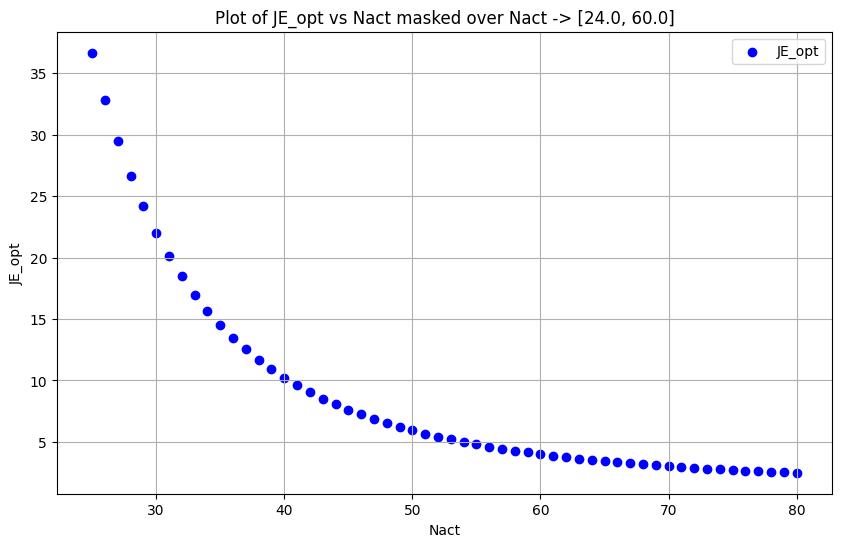

,Nact,JE_opt
0,2.0,87561.505409
1,3.0,21905.386638
2,4.0,8770.567662
3,5.0,4390.698410
4,6.0,2512.757565
5,7.0,1573.275553
6,8.0,1051.010148
7,9.0,737.424470
8,10.0,537.708253
9,11.0,404.444677


We select a JE_opt value of: 4.0 given Nact = 60


In [52]:
num_neurons = 120

def computeOptimalJe(numNeurons = 120):
    Nact = np.linspace(2, numNeurons-2, numNeurons-3)
    n_tilde = Nact - numNeurons/2
    deltaTheta = 2*pi/numNeurons

    JE_inv = 1/4 + (n_tilde+sin(n_tilde*deltaTheta)/sin(deltaTheta))/(2*numNeurons)
    JE_opt = 1/JE_inv
    return JE_opt, JE_inv, Nact

JE_opt, JE_inv, Nact = computeOptimalJe(num_neurons)

# Plotting JE_opt
fig = plt.figure(figsize=(10, 6))
mask = (Nact <= num_neurons/1.5) & (Nact > num_neurons/5)
plt.scatter(Nact[mask], JE_opt[mask], label='JE_opt', color='blue')
plt.xlabel('Nact')
plt.ylabel('JE_opt')
plt.title(f'Plot of JE_opt vs Nact masked over Nact -> [{num_neurons/5}, {num_neurons/2}]')
plt.legend()
plt.grid()
plt.show()

JE_df = pd.DataFrame({'Nact': Nact, 'JE_opt': JE_opt})
display(JE_df.head(50))

JE_chosen = JE_df[JE_df['Nact'] == num_neurons//2]['JE_opt'].iloc[0]
print("We select a JE_opt value of:", JE_chosen, "given Nact =", num_neurons//2)

In [53]:
# Setting network parameters
tau = 10*ms
sigma_noise=0.0*mV
V_rest=-70*mV

# neuron group
Vth=-48*mV
V_reset=-80*mV
refractory_period=0.0*ms
glob_inh_flag = True

# Connectivity parameters - Cosine
g_cosine = 69.51337004749652*mV
w_inh = -103.92710109941913*mV

# g_cosine = 4.0*mV
# w_inh = -15.711552941512165*mV

I0 = 22*mV

In [54]:
# Creating the equation object
neuron_eq = Equations(LIF_xi_vel_eq, tau=tau, V_rest=V_rest, sigma_noise=sigma_noise)
            
ringAttractor = RingAttractor(neuron_eq, 
                        num_neurons, 
                        Vth, V_reset, refractory_period,
                        syn_profile='cosine',
                        autapse=False, normalized=True,
                        glob_inh=glob_inh_flag, w_inh=w_inh,
                        g_cosine=g_cosine)


ringAttractor.ring_pool.run_regularly('V = clip(V, V_reset, inf*volt)', dt=defaultclock.dt)

CodeRunner(clock=Clock(dt=100. * usecond, name='ring_neurons_run_regularly_clock_4'), when=start, order=0, name='ring_neurons_run_regularly')

In [55]:
# Setup monitors: spike monitor and state monitor for membrane potential and external input
spikemon = SpikeMonitor(ringAttractor.ring_pool)
inputmon = StateMonitor(ringAttractor.ring_pool, 'I_ext', record=True)  # if you want to check the input

# Set of Brian objects to be added to the network
localObjects = [spikemon, inputmon]

net = Network(ringAttractor.BrianObjects+localObjects)

In [56]:
ringAttractor.ring_pool.I_ext = I0
ringAttractor.ring_pool.I_ext[num_neurons//2] += 1.0*mV
ringAttractor.ring_pool.I_vel = 0.0
ringAttractor.ring_synapses_asym.vel_on = False
phase1_duration = 1 * second
net.run(phase1_duration)

ringAttractor.ring_synapses_asym.vel_on = True
phase2_duration = 1 * second
net.run(phase2_duration)

ringAttractor.ring_synapses_asym.vel_on = False
phase3_duration = 1 * second
net.run(phase3_duration)

total_duration = phase1_duration + phase2_duration + phase3_duration

In [57]:
if deviceType == 'cpp_standalone':
    device.build(directory = 'model_build', compile=True, run=False, debug=False, clean=False)

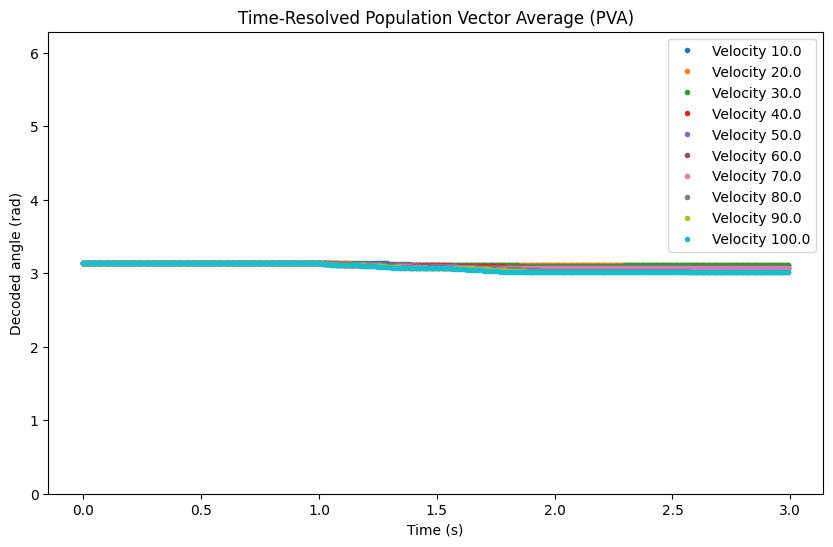

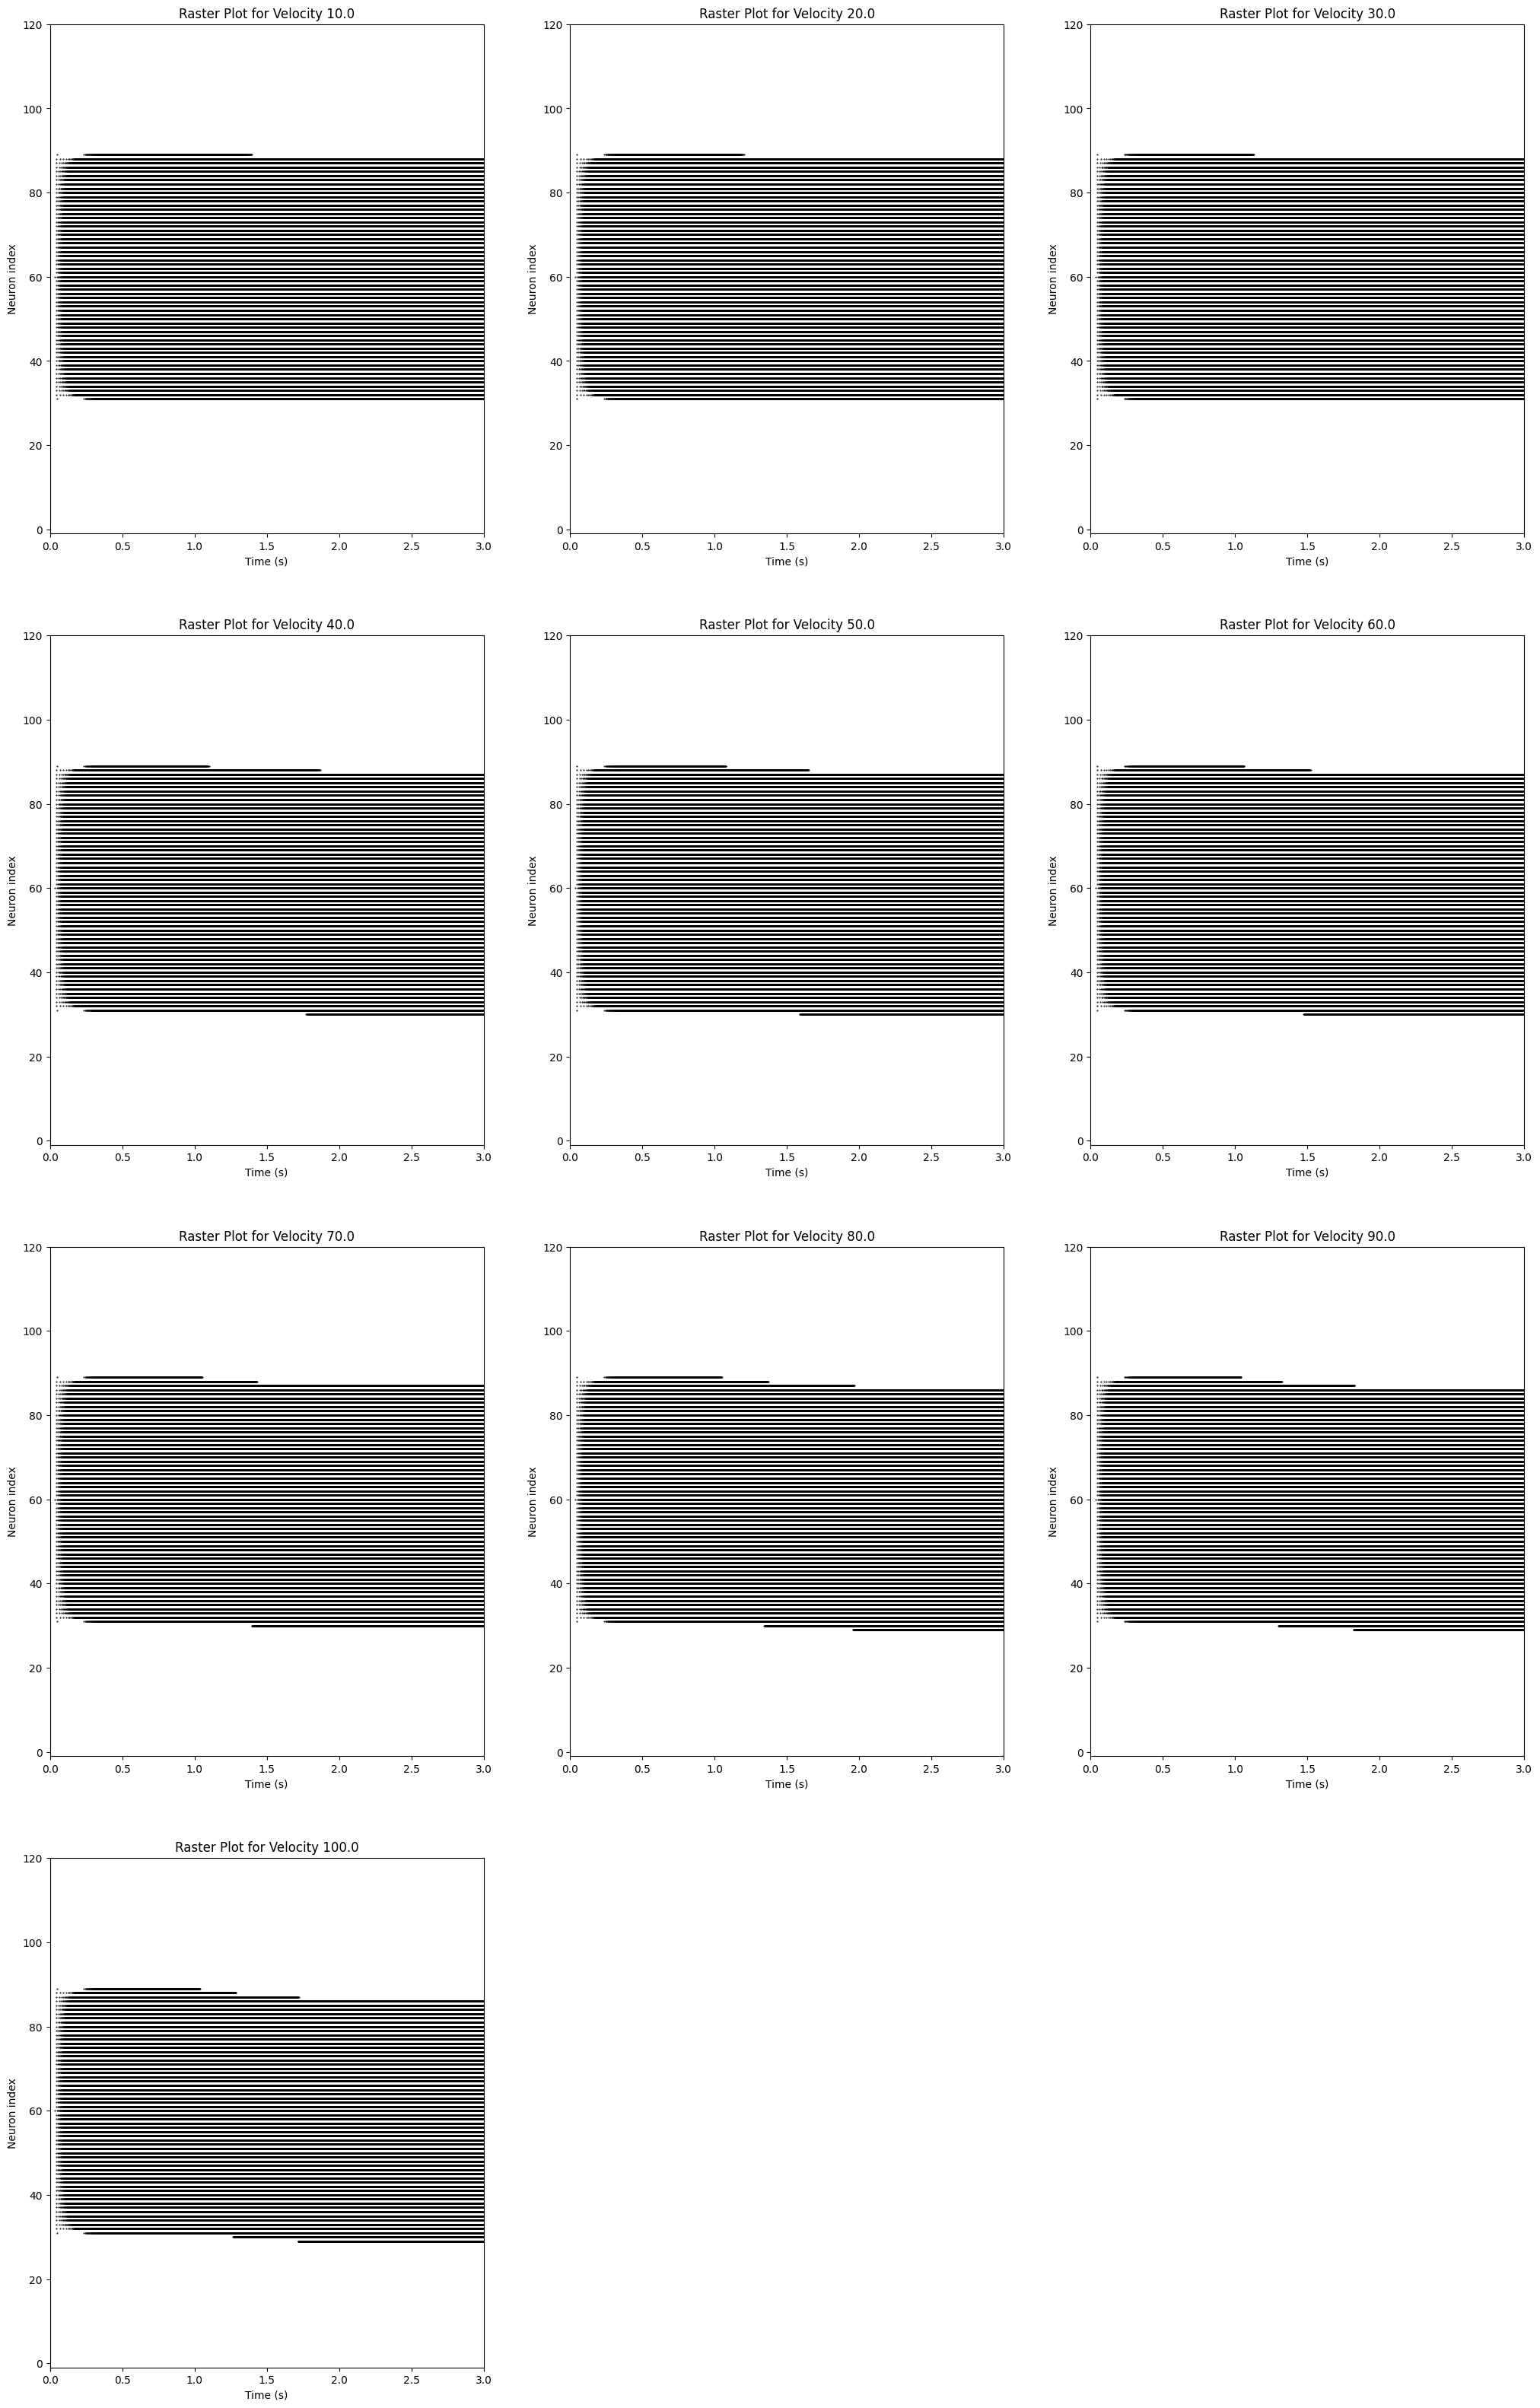

In [58]:
positions = np.linspace(0, 2*np.pi, num_neurons, endpoint=False)
window_size = 50 * ms
step_size = 10 * ms
velocity_input = linspace(10, 100, 10)

time_windows = []
fig1, ax = plt.subplots(figsize=(10, 6))

# Dynamically determine the number of rows and columns for subplots
num_plots = len(velocity_input) if runFullSim else 1
cols = 3  # Number of columns (you can adjust this as needed)
rows = (num_plots + cols - 1) // cols  # Calculate the number of rows needed

# Create the subplots
fig2, axes = plt.subplots(rows, cols, figsize=(25, 10 * rows))  # Adjust figure size based on rows
# Flatten the axes array for easy indexing (handle the case when there's only one plot)
axes = np.atleast_1d(axes.flatten() if hasattr(axes, 'flatten') else axes)

if deviceType == 'cpp_standalone':
    velocity_input = velocity_input if runFullSim else velocity_input[0:1]
    results = []
    for iter, vel in enumerate(velocity_input):
        device.run(run_args={ringAttractor.ring_synapses_asym.vel_in: vel},
                   results_directory=f'result_{iter}')
        time_resolved_PVA(spikemon, positions, total_duration, num_neurons, window_size=window_size,
                          ax=ax, label=f"Velocity {vel}")
        pva_angles, time_windows = computePVATT(spikemon, positions, total_duration, num_neurons,
                                                window_size, step_size)
        results.append(pva_angles)
        
        ax2 = axes[iter]
        raster_plot(spikemon, ax=ax2, duration=total_duration, num_neurons=num_neurons, y_axisFull=True)
        ax2.set_title(f"Raster Plot for Velocity {vel}")
        
# Hide any unused subplots
for j in range(num_plots, len(axes)):
    axes[j].axis('off')

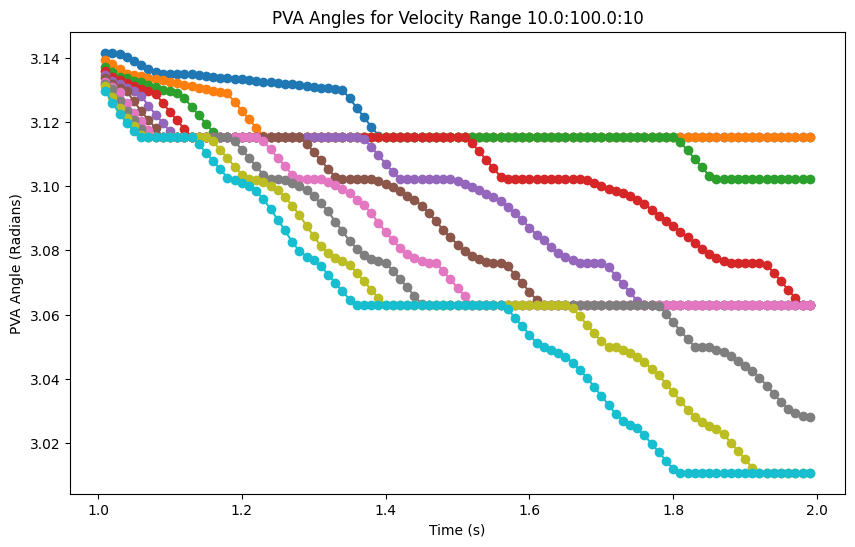

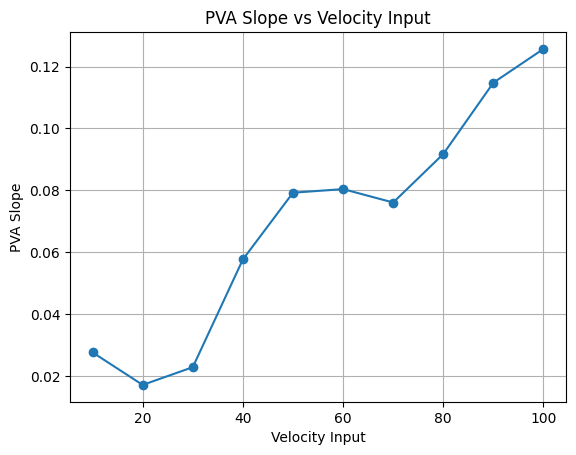

In [59]:
pva_slopes = []
time_windows_au = time_windows.copy()/second
mask = (time_windows_au > 1.0) & (time_windows_au < 2.0)
time_windows_au = time_windows_au[mask]


fig2 = plt.figure(figsize=(10, 6))
for result in results:
    # Calculate the slope of the PVA angles within the masked time window
    pva_slope = np.polyfit(time_windows_au, result[mask], 1)[0]
    pva_slopes.append(pva_slope)
    plt.plot(time_windows_au, result[mask], marker='o')
    plt.xlabel('Time (s)'), 
    plt.ylabel('PVA Angle (Radians)')
    plt.title(f'PVA Angles for Velocity Range {velocity_input[0]}:{velocity_input[-1]}:{len(velocity_input)}')
    plt.grid()

plt.show(block=True)


fig3 = plt.figure()
plt.plot(velocity_input, abs(np.asarray(pva_slopes)), marker='o')
plt.xlabel('Velocity Input')
plt.ylabel('PVA Slope')
plt.title('PVA Slope vs Velocity Input')
plt.grid()

# fig4 = plt.figure()
# plt.plot(normalized_velocity, ratio, marker='o')
# plt.xlabel('Velocity Input')
# plt.ylabel('PVA Slope')
# plt.title('PVA Slope vs Velocity Input')
# plt.grid()
# plt.show(block=True)

In [60]:
if not runFullSim:    
    from matplotlib.ticker import FuncFormatter
    from sympy import Rational


    #+---------------------------------------------------------------------------+
    #|                           Plotting the Results                            |
    #+---------------------------------------------------------------------------+

    # Create a figure with 6 subplots arranged in 3 rows and 2 columns
    fig = plt.figure(figsize=(20,20))

    positions = linspace(0, 2*pi, num_neurons, endpoint=False)
    # Define the formatter function
    def pi_formatter(x, pos):
        # Convert the value to a fraction of pi
        frac = Rational(x).limit_denominator(10)  # Limit denominator to avoid too large fractions
        if frac == 0:
            return r"$0$"
        elif frac == 2:
            return r"$2\pi$"
        else:
            return r"${}\pi$".format(frac)


    # 1. Input Current Plot
    ax1 = fig.add_subplot(3, 2, 1)
    ax1.plot(positions/pi, ringAttractor.ring_pool.I_ext/mV)
    # Set the custom formatter for the x-axis
    ax1.xaxis.set_major_formatter(FuncFormatter(pi_formatter))
    ax1.set_title('Input Current')
    ax1.set_xlabel('Position (rad)')
    ax1.set_ylabel('Current (mV)')


    # 2. Raster Plot
    ax2 = fig.add_subplot(3, 2, 2)
    raster_plot(spikemon, ax=ax2, duration=total_duration, num_neurons=num_neurons, y_axisFull=True)


    # 3. Firing Rate Profile Plot
    ax3 = fig.add_subplot(3, 2, 3)
    firing_rate, _ = firing_rate_profile(spikemon, positions/pi, total_duration, ax=ax3)
    ax3.xaxis.set_major_formatter(FuncFormatter(pi_formatter))


    ax4 = fig.add_subplot(3, 2, 4)
    firing_rateInstant, _ = firing_rate_profile(spikemon, positions/pi, total_duration, ax=ax4, instantRate=True)
    ax4.xaxis.set_major_formatter(FuncFormatter(pi_formatter))



    # 4. Polar Plot of the Population Vector Average (PVA)
    ax5 = fig.add_subplot(3, 2, 5, projection='polar')
    polar_plot_PVA(firing_rateInstant, positions, scale=1.2, ax=ax5)

    # 5. Time-Resolved PVA Plot
    ax6 = fig.add_subplot(3, 2, 6)
    _, _ = time_resolved_PVA(spikemon, positions, total_duration, num_neurons,
                            window_size=50*ms, ax=ax6)
    ax6.yaxis.set_major_formatter(FuncFormatter(pi_formatter))



    # Create the 3D instantaneous firing rate plot
    fig, ax = instantRateTT_plot(spikemon, positions, total_duration, num_neurons=num_neurons)

    # Optional: adjust the view angle for better visualization
    ax.view_init(elev=20, azim=-35)

    # # 6. Membrane potential traces
    # ax7 = fig.add_subplot(3, 2, 7)
    # membrane_potential_traces(statemon, total_duration, Vth = Vth, ax=ax7)

    plt.tight_layout()
    plt.show(block=True)